In [1]:
import numpy as np
from importlib import reload
import utils
import constants
from utils import *
from constants import *

reload(constants)
reload(utils)


The User Guide is currently not available.


<module 'utils' from '/media/team_workspaces/AnomalyMatch-JWST-Lenses/CODE/utils.py'>

In [12]:
import anomaly_match as am
import pandas as pd

# We use a cfg DotMap (a dictionary with dot accessors) to store the configuration for the run
cfg = am.get_default_cfg()
cfg.name = "dataset_v2_run_2"

# Path to a model you may load
cfg.model_path = '/media/home/team_workspaces/AnomalyMatch-JWST-Lenses/dataset_v2/model/model_iteration_0.pth'

# Set the data directory
# This directory should contain the images to be used for active labeling and training and testing
cfg.data_dir = '/media/home/team_workspaces/AnomalyMatch-JWST-Lenses/dataset_v2/training_images/'
# Set the label file
cfg.label_file = '/media/home/team_workspaces/AnomalyMatch-JWST-Lenses/dataset_v2/labeled_data_all_lenses_w_replacements.csv'  # CSV mapping annotated images to labels

# Set metadata file
cfg.metadata_file = cfg.label_file # CSV mapping images to metadata such as sourceID, ra, dec (optional)

# Set the search directory
# You can predict on a large unlabeled dataset (*.hdf5, ideally) by setting this to the directory containing the unlabeled images / files
# This will be triggered when you press evaluate_search_dir
cfg.prediction_search_dir = f'/media/home/team_workspaces/AnomalyMatch-JWST-Lenses/dataset_v2/all_images_zarr_splits/folder_{1}/'

# Normalisation method to use when loading images, can be adjusted in the GUI
cfg.normalisation_method = am.NormalisationMethod.CONVERSION_ONLY

# Set the test ratio
cfg.test_ratio = 0.33 # Proportion of data used for evaluation (0.0 disables test evaluation, > 0 shows AUROC/AUPRC curves)

# Set the number of unlabeled images to load
# cfg.N_to_load = 100  # Number of unlabeled images loaded into the training dataset at once
cfg.seed = 42

# Set the image size
cfg.size = [224, 224]  # Dimensions to which images are resized (below 96x96 is not recommended)

# Set the logger level (options: "trace","debug", "info", "warning", "error", "critical")
logger_level = "info"
am.set_log_level(logger_level, cfg)

# Create a session
session = am.Session(cfg)

09:15:15|AnomalyMatch-WARNING| Found unexpected keys in config: ['normalisation_method']
09:15:15|AnomalyMatch-INFO| Config: validation partially successful
09:15:17|AnomalyMatch-WARNING| Number of entries in metadata file (458) does not match number of images (614029)
09:15:17|AnomalyMatch-INFO| Successfully loaded metadata for 458 files
09:15:17|AnomalyMatch-INFO| Found 614029 total images in /media/home/team_workspaces/AnomalyMatch-JWST-Lenses/DATA/dataset_v2/training_images/
Loading batch 0: 100%|██████████| 1000/1000 [00:00<00:00, 2007.00it/s]
09:15:31|AnomalyMatch-WARNING| Number of entries in metadata file (458) does not match number of images (614029)
09:15:31|AnomalyMatch-INFO| Successfully loaded metadata for 458 files
09:15:31|AnomalyMatch-INFO| Found 614029 total images in /media/home/team_workspaces/AnomalyMatch-JWST-Lenses/DATA/dataset_v2/training_images/
Loading batch 0: 100%|██████████| 1000/1000 [00:00<00:00, 2019.22it/s]
09:15:44|AnomalyMatch-WARNING| Bundled pretrain

In [13]:
# Start the UI

session.start_UI()

Output(layout=Layout(border_bottom='1px solid white', border_left='1px solid white', border_right='1px solid w…

Traceback (most recent call last):
  File "/home/doryan/.conda/envs/am/lib/python3.11/multiprocessing/queues.py", line 239, in _feed
    reader_close()
  File "/home/doryan/.conda/envs/am/lib/python3.11/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/home/doryan/.conda/envs/am/lib/python3.11/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


## De-duplication of lenses within a radius

Cluster ID: 2
0 astrodeep_jw02561-o001_t003_nircam_clear-3.536801--30.361442.png
1 astrodeep_jw01324-o001_t001_nircam_clear-3.532148--30.36038.png


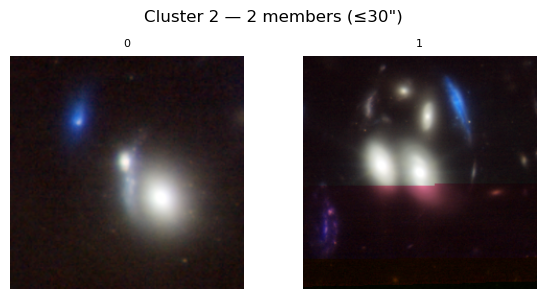

Cluster ID: 3
0 astrodeep_jw02561-o003_t006_nircam_clear-3.620714--30.36954.png
1 astrodeep_jw02561-o003_t006_nircam_clear-3.623007--30.376999.png
2 astrodeep_jw02561-o003_t006_nircam_clear-3.623365--30.369149.png


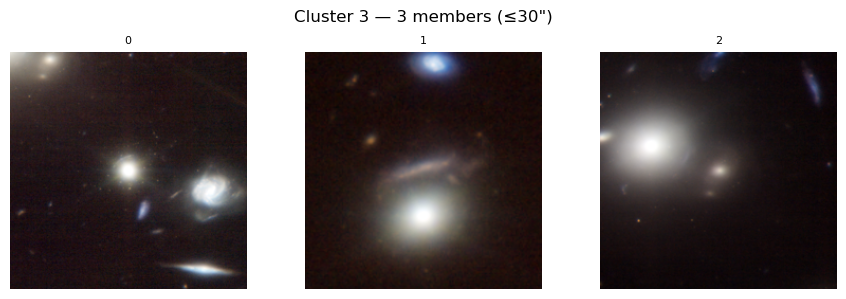

Cluster ID: 12
0 astrodeep_jw02561-o001_t003_nircam_clear-3.585307--30.387526.png
1 astrodeep_jw02561-o001_t003_nircam_clear-3.587399--30.393291.png
2 astrodeep_jw02561-o001_t003_nircam_clear-3.595497--30.388669.png
3 astrodeep_jw02561-o001_t003_nircam_clear-3.588142--30.39506.png
4 astrodeep_jw02561-o001_t003_nircam_clear-3.588866--30.391797.png


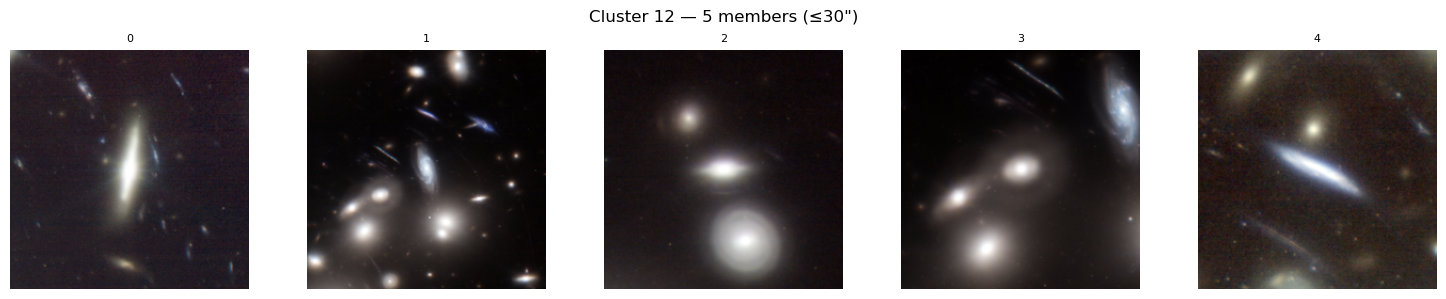

Cluster ID: 13
0 astrodeep_jw02561-o003_t006_nircam_clear-3.579403--30.358357.png
1 astrodeep_jw02561-o003_t006_nircam_clear-3.578037--30.359454.png


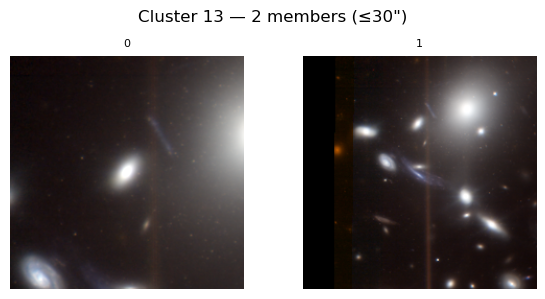

Cluster ID: 37
0 cosmos_jw01727-o091_t061_nircam_clear-150.0496918200376-2.217150081889714.png
1 cosmos_jw01727-o091_t061_nircam_clear-150.04830349054535-2.2140987349522723.png


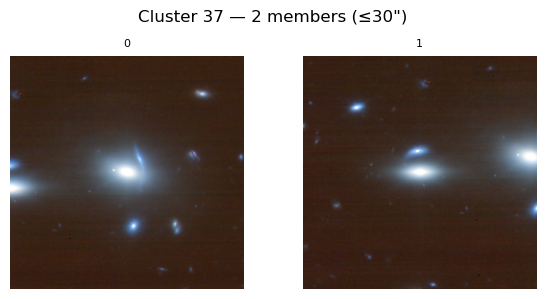

Cluster ID: 44
0 astrodeep_jw02561-o001_t003_nircam_clear-3.568635--30.392247.png
1 astrodeep_jw02561-o001_t003_nircam_clear-3.572354--30.395965.png
2 astrodeep_jw02561-o001_t003_nircam_clear-3.574892--30.398356.png


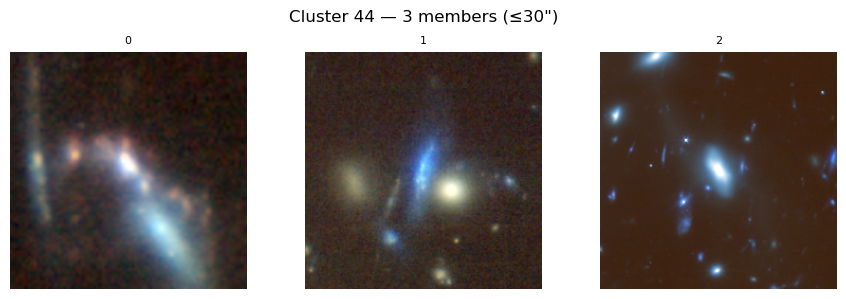

Cluster ID: 57
0 astrodeep_jw01324-o006_t002_nircam_clear-3.495445--30.361379.png
1 astrodeep_jw01324-o006_t002_nircam_clear-3.499966--30.359605.png


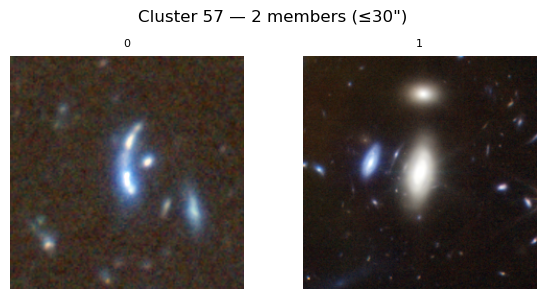

In [32]:
''' 
DBSCAN Euclidean distance clustering of source coordinates. 
- Sources should have the 'RA' and 'DEC' columns.
- A source is considered duplicate when part of a multi-source cluster within a `cluster_size` radius. 
- However, manual inspection is needed for positive outcomes as real neighboring sources can be closer than the clustering radius.
'''

import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.cluster import DBSCAN

# -------------------
# Parameters
# -------------------

cluster_size = 30.0 # arcsec
base_dir = Path("/media/home/team_workspaces/AnomalyMatch-JWST-Lenses/dataset_v2/training_images/") # dir where to find the images
outdir = Path("cluster_panels")
outdir.mkdir(exist_ok=True)

df = pd.read_csv(cfg.label_file)
coords = SkyCoord(df["RA"].values * u.deg, df["DEC"].values * u.deg)
X = np.vstack([coords.ra.radian, coords.dec.radian]).T
eps_rad = (cluster_size * u.arcsec).to(u.rad).value
labels = DBSCAN(eps=eps_rad, min_samples=1, metric="euclidean").fit_predict(X)
df["cluster_id"] = labels

sizes = df["cluster_id"].value_counts()
multi_ids = sizes.index[sizes > 1]

zscale = ZScaleInterval()

def read_any_image(path: Path):
    ext = path.suffix.lower()
    if ext in {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".webp"}:
        return np.asarray(Image.open(path))
    with fits.open(path) as hdul:
        if "SCI" in hdul:
            data = hdul["SCI"].data
        else:
            hdu = next((h for h in hdul if getattr(h, "data", None) is not None and np.ndim(h.data) >= 2), None)
            if hdu is None:
                raise ValueError(f"No 2D image in {path}")
            data = hdu.data
        data = np.asarray(data).squeeze()
        if data.ndim > 2:
            data = data[0]
        vmin, vmax = zscale.get_limits(data)
        return (data, vmin, vmax)

for cid in sorted(multi_ids):
    rows = df[df["cluster_id"] == cid].reset_index(drop=True)
    n = len(rows)
    ncols = min(5, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    axes = np.atleast_2d(axes)
    print('Cluster ID:', cid)
    
    for i, row in rows.iterrows():
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        try:
            p = Path(row.get("filename"))
            print(i, p.name)

            if not p.is_absolute():
                p = base_dir / p
            img = read_any_image(p)
            if isinstance(img, tuple):
                data, vmin, vmax = img
                ax.imshow(data, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
            else:
                ax.imshow(img, origin="lower")
            ax.set_title(i, fontsize=8)
        except Exception as e:
            ax.text(0.5, 0.5, f"Failed:\n{p.name}\n{e}", ha="center", va="center", fontsize=7)
        ax.set_axis_off()

    for k in range(n, nrows * ncols):
        r, c = divmod(k, ncols)
        axes[r, c].set_visible(False)

    fig.suptitle(f"Cluster {cid} — {n} members (≤30\")", y=0.98, fontsize=12)
    fig.tight_layout()
    fig.savefig(outdir / f"cluster_{cid}.png", dpi=150)
    plt.show()